Saving synthetic_crime_data.csv to synthetic_crime_data (2).csv

🔮 Predicted Crime Types at the given location/time:
➡️ Robbery


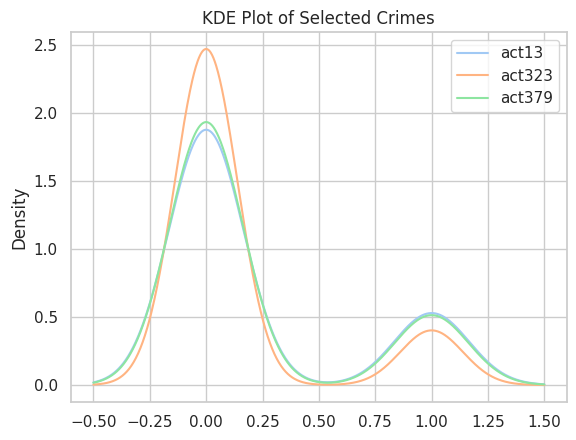

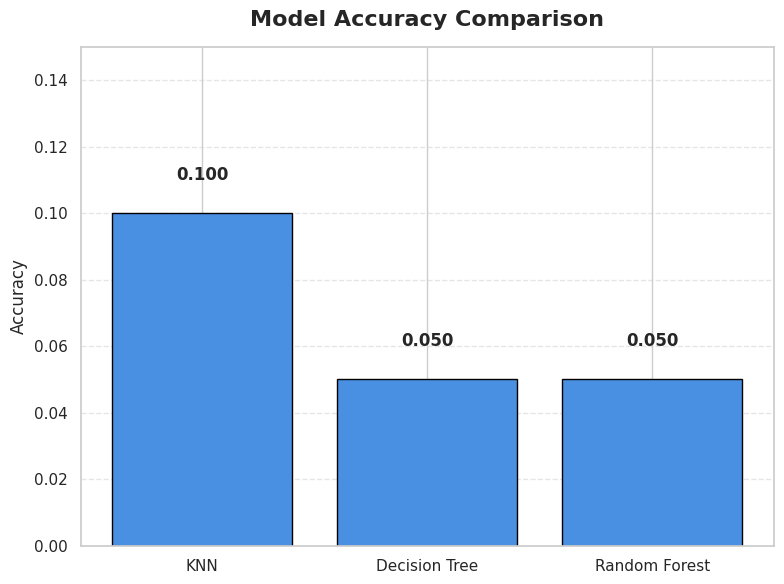


📈 Model Accuracy Scores:
KNN Accuracy:           0.1000
Decision Tree Accuracy: 0.0500
Random Forest Accuracy: 0.0500


In [3]:
# ================================================
# ✅ Step 1: Upload CSV File (Google Colab)
# ================================================
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ================================================
# ✅ Step 2: Load the Uploaded File
# ================================================
data = pd.read_csv('synthetic_crime_data')

# ================================================
# 🕒 Step 3: Parse and Process Timestamp
# ================================================
data['timestamp'] = pd.to_datetime(data['timestamp'], dayfirst=True, errors='coerce')
data.dropna(subset=['timestamp'], inplace=True)

dt = data['timestamp']
iso = dt.dt.isocalendar()

datetime_features = pd.DataFrame({
    'year': dt.dt.year,
    'month': dt.dt.month,
    'day': dt.dt.day,
    'hour': dt.dt.hour,
    'dayofyear': dt.dt.dayofyear,
    'week': iso.week,
    'dayofweek': dt.dt.dayofweek,
    'weekday': dt.dt.weekday,
    'quarter': dt.dt.quarter,
})

# ================================================
# 🔀 Step 4: Combine With Other Features
# ================================================
data_no_time = data.drop('timestamp', axis=1)
data1 = pd.concat([datetime_features, data_no_time], axis=1)
data1.dropna(inplace=True)

# ================================================
# 📊 Step 5: KDE Plot (Optional)
# ================================================
df_kde = data1[['act13', 'act323', 'act379']]
df_kde.plot.kde(title="KDE Plot of Selected Crimes")

# ================================================
# 🎯 Step 6: Feature and Label Separation
# ================================================
X = data1[['month', 'day', 'hour', 'dayofyear', 'week', 'latitude', 'longitude']].values
y = data1[['act379', 'act13', 'act279', 'act323', 'act363', 'act302']].values

# ================================================
# ✂️ Step 7: Train-Test Split
# ================================================
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=50)

# ================================================
# 🧠 Step 8: Train Models (MultiOutput)
# ================================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier

# KNN
knn = KNeighborsClassifier(n_neighbors=3)  # safer for small datasets
multi_knn = MultiOutputClassifier(knn)
multi_knn.fit(X_train, y_train)
acc1 = multi_knn.score(X_test, y_test)

# Decision Tree
dtree = DecisionTreeClassifier(max_depth=100, random_state=300)
multi_dtree = MultiOutputClassifier(dtree)
multi_dtree.fit(X_train, y_train)
acc2 = multi_dtree.score(X_test, y_test)

# Random Forest
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
multi_rfc = MultiOutputClassifier(rfc)
multi_rfc.fit(X_train, y_train)
acc3 = multi_rfc.score(X_test, y_test)

# ================================================
# 🔍 Step 9: Sample Crime Prediction
# ================================================
test_sample = np.array([2., 28., 15., 59., 9., 22.723873, 75.828416]).reshape(1, -1)
predicted_labels = multi_rfc.predict(test_sample)[0]

crime_labels = ['Robbery', 'Gambling', 'Accident', 'Violence', 'Kidnapping', 'Murder']

print("\n🔮 Predicted Crime Types at the given location/time:")
for i, label in enumerate(predicted_labels):
    if label == 1:
        print(f"➡️ {crime_labels[i]}")

# ================================================
# 📊 Step 10: Clean Single-Color Accuracy Chart (Full Y-Axis)
# ================================================
models = ['KNN', 'Decision Tree', 'Random Forest']
accuracies = [acc1, acc2, acc3]

plt.figure(figsize=(8, 6))

# Use one solid color for all bars
bar_color = '#4A90E2'
bars = plt.bar(models, accuracies, color=bar_color, edgecolor='black')

plt.title("Model Accuracy Comparison", fontsize=16, fontweight='bold', pad=15)
plt.ylabel("Accuracy", fontsize=12)

# Fill Y-axis height nicely
max_acc = max(accuracies)
plt.ylim(0, max_acc + 0.05)

# Add text labels above bars
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.01, f"{acc:.3f}", ha='center', fontsize=12, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ================================================
# 📈 Step 11: Print Accuracy Scores
# ================================================
print("\n📈 Model Accuracy Scores:")
print(f"KNN Accuracy:           {acc1:.4f}")
print(f"Decision Tree Accuracy: {acc2:.4f}")
print(f"Random Forest Accuracy: {acc3:.4f}")
